In [1]:
!pip install fastf1 pandas numpy scikit-learn matplotlib seaborn plotly joblib --quiet

In [2]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib, os, warnings
warnings.filterwarnings('ignore')

fastf1.Cache.enable_cache('f1_cache')
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("All good!")

All good!


In [3]:
# Load qualifying sessions — cleaner signal than race for driver style
# (no traffic, fuel load effects, safety cars)
sessions_to_load = [
    (2024, 'Bahrain', 'Q'),
    (2024, 'Monaco', 'Q'),
    (2024, 'Britain', 'Q'),
    (2024, 'Italy', 'Q'),
    (2026, 'Australia', 'Q'),
    (2026, 'Japan', 'Q'),
]

all_telemetry = []

for year, race, session_type in sessions_to_load:
    print(f"Loading {race} {year} {session_type}...")
    try:
        session = fastf1.get_session(year, race, session_type)
        session.load(telemetry=True, weather=False, messages=False)

        for driver in session.drivers:
            try:
                lap = session.laps.pick_driver(driver).pick_fastest()
                if lap.empty:
                    continue
                tel = lap.get_telemetry().add_distance()
                tel['Driver'] = session.get_driver(driver)['Abbreviation']
                tel['Team'] = lap['Team']
                tel['race'] = f"{race}{year}"
                tel['year'] = year
                all_telemetry.append(tel)
            except Exception:
                continue

        print(f"  Done")
    except Exception as e:
        print(f"  Skipped: {e}")

df_tel = pd.concat(all_telemetry, ignore_index=True)
print(f"\nTotal telemetry rows: {df_tel.shape[0]}")
print(f"Columns: {df_tel.columns.tolist()}")

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading Bahrain 2024 Q...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']
core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  Done
Loading Monaco 2024 Q...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '31', '3', '18', '27', '14', '2', '20', '11', '77', '24']
events      WARNING 	Correcting user input 'Britain' to 'British Grand Prix'
core           INFO 	Loading data for British Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '18'


...

  Done
Loading Australia 2026 Q...


core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '6', '16', '81', '1', '44', '30', '41', '5', '27', '87', '31', '10', '23', '43', '14', '11', '77', '18', '3', '55']
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  Done
Loading Japan 2026 Q...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '81', '16', '1', '44', '10', '6', '5', '41', '3', '31', '27', '30', '43', '55', '23', '87', '11', '77', '14', '18']


  Done

Total telemetry rows: 76721
Columns: ['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'RelativeDistance', 'Status', 'X', 'Y', 'Z', 'Distance', 'Driver', 'Team', 'race', 'year']


In [4]:
def extract_driver_dna(df_tel):
    """
    Extract 8 driving style features per driver per session
    from raw telemetry data
    """
    records = []
    
    for (driver, race), group in df_tel.groupby(['Driver', 'race']):
        if len(group) < 500:  # skip if not enough data
            continue
        
        throttle = group['Throttle'].fillna(0)
        brake = group['Brake'].fillna(0)
        speed = group['Speed'].fillna(0)
        
        # 1. Full throttle % — how much time at 100% throttle
        full_throttle_pct = (throttle >= 98).sum() / len(throttle) * 100
        
        # 2. Heavy braking % — time with brake fully pressed
        heavy_brake_pct = (brake == True).sum() / len(brake) * 100
        
        # 3. Avg corner speed — speed when throttle < 20% (cornering zones)
        cornering = group[throttle < 20]['Speed']
        avg_corner_speed = cornering.mean() if len(cornering) > 0 else 0
        
        # 4. Throttle smoothness — lower std = smoother inputs
        throttle_std = throttle.std()
        
        # 5. Coast % — neither throttle nor brake (lift and coast)
        coast_pct = ((throttle < 5) & (brake == False)).sum() / len(group) * 100
        
        # 6. High speed % — time above 280 km/h
        high_speed_pct = (speed > 280).sum() / len(speed) * 100
        
        # 7. Max speed
        max_speed = speed.max()
        
        # 8. Brake aggression — how quickly brake is applied
        # proxy: variance in brake signal transitions
        brake_int = brake.astype(int)
        brake_transitions = brake_int.diff().abs().sum()
        brake_aggression = brake_transitions / len(brake) * 100

        team = group['Team'].iloc[0]
        year = group['year'].iloc[0]
        
        records.append({
            'driver': driver,
            'race': race,
            'year': year,
            'team': team,
            'full_throttle_pct': round(full_throttle_pct, 2),
            'heavy_brake_pct': round(heavy_brake_pct, 2),
            'avg_corner_speed': round(avg_corner_speed, 2),
            'throttle_smoothness': round(throttle_std, 2),
            'coast_pct': round(coast_pct, 2),
            'high_speed_pct': round(high_speed_pct, 2),
            'max_speed': round(max_speed, 2),
            'brake_aggression': round(brake_aggression, 2),
        })
    
    return pd.DataFrame(records)

dna_df = extract_driver_dna(df_tel)
print(f"Driver DNA profiles: {dna_df.shape[0]}")
print(f"Unique drivers: {dna_df['driver'].nunique()}")
print(dna_df.head(10))

Driver DNA profiles: 120
Unique drivers: 27
  driver           race  year          team  full_throttle_pct  \
0    ALB  Australia2026  2026      Williams              53.36   
1    ALB    Bahrain2024  2024      Williams              58.57   
2    ALB    Britain2024  2024      Williams              66.27   
3    ALB      Italy2024  2024      Williams              72.82   
4    ALB      Japan2026  2026      Williams              57.66   
5    ALO  Australia2026  2026  Aston Martin              64.19   
6    ALO    Bahrain2024  2024  Aston Martin              65.41   
7    ALO    Britain2024  2024  Aston Martin              66.10   
8    ALO      Italy2024  2024  Aston Martin              72.96   
9    ALO      Japan2026  2026  Aston Martin              58.47   

   heavy_brake_pct  avg_corner_speed  throttle_smoothness  coast_pct  \
0            13.42            196.95                39.95       6.87   
1            20.50            153.42                41.35       1.46   
2            

In [5]:
# Average DNA features per driver across all sessions
DNA_FEATURES = [
    'full_throttle_pct', 'heavy_brake_pct', 'avg_corner_speed',
    'throttle_smoothness', 'coast_pct', 'high_speed_pct',
    'max_speed', 'brake_aggression'
]

driver_dna = dna_df.groupby(['driver', 'team'])[DNA_FEATURES].mean().reset_index()
driver_dna['team'] = driver_dna['team'].fillna('Unknown')

print(f"Unique drivers with DNA profiles: {len(driver_dna)}")
print(driver_dna[['driver', 'team'] + DNA_FEATURES].round(2))

Unique drivers with DNA profiles: 34
   driver             team  full_throttle_pct  heavy_brake_pct  \
0     ALB         Williams              61.74            19.82   
1     ALO     Aston Martin              61.36            15.84   
2     ANT         Mercedes              63.67            27.42   
3     BEA     Haas F1 Team              60.24            13.66   
4     BOR             Audi              64.39            23.90   
5     BOT         Cadillac              56.42            15.18   
6     BOT      Kick Sauber              59.29            19.88   
7     COL           Alpine              63.32            26.78   
8     COL         Williams              69.22            14.66   
9     GAS           Alpine              56.86            17.29   
10    HAD  Red Bull Racing              57.10            12.48   
11    HAM          Ferrari              60.78            10.17   
12    HAM         Mercedes              62.67            17.52   
13    HUL             Audi             

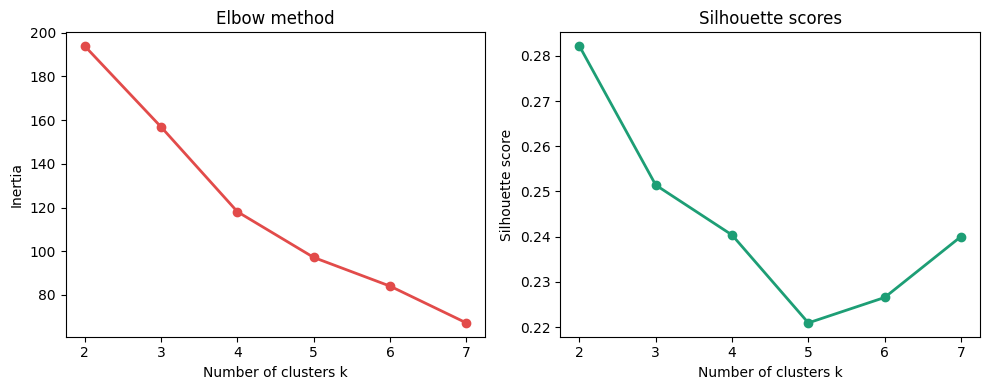


Best k by silhouette: 2
Silhouette scores: [0.282, 0.251, 0.24, 0.221, 0.227, 0.24]


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(driver_dna[DNA_FEATURES])

# Find optimal number of clusters
inertias = []
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot elbow + silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(k_range, inertias, 'o-', color='#E24B4A', linewidth=2)
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow method')
ax2.plot(k_range, silhouettes, 'o-', color='#1D9E75', linewidth=2)
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette scores')
plt.tight_layout()
plt.savefig('plots/optimal_k.png', dpi=150)
plt.show()

best_k = k_range[silhouettes.index(max(silhouettes))]
print(f"\nBest k by silhouette: {best_k}")
print(f"Silhouette scores: {[round(s,3) for s in silhouettes]}")

In [7]:
# Force k=4 for meaningful archetypes
km = KMeans(n_clusters=4, random_state=42, n_init=10)
driver_dna['cluster'] = km.fit_predict(X_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
driver_dna['pca_x'] = coords[:, 0]
driver_dna['pca_y'] = coords[:, 1]

print(f"PCA variance explained: {pca.explained_variance_ratio_.round(3)}")
print(f"\nDrivers per cluster:")
print(driver_dna.groupby('cluster')['driver'].apply(list))

# Check cluster centers to name archetypes
centers = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=DNA_FEATURES
)
print(f"\nCluster centers:")
print(centers[['full_throttle_pct','heavy_brake_pct','avg_corner_speed','throttle_smoothness']].round(2))

PCA variance explained: [0.435 0.236]

Drivers per cluster:
cluster
0                            [ANT, BOR, COL, HUL, OCO]
1    [ALB, ALO, BEA, HAD, HAM, LAW, LEC, LIN, NOR, ...
2                                                [COL]
3    [BOT, BOT, GAS, HAM, HUL, MAG, OCO, PER, SAI, ...
Name: driver, dtype: object

Cluster centers:
   full_throttle_pct  heavy_brake_pct  avg_corner_speed  throttle_smoothness
0              64.04            25.18            180.40                35.50
1              60.83            15.42            172.96                38.71
2              69.22            14.66            186.86                37.38
3              58.92            19.09            161.58                39.67


In [8]:
# COL is a solo outlier — reassign to nearest cluster (1)
driver_dna.loc[driver_dna['cluster'] == 2, 'cluster'] = 1

# Name the archetypes based on cluster center analysis
archetype_map = {
    0: 'Aggressive Chargers',
    1: 'Calculated Racers', 
    3: 'Tire Whisperers',
}
driver_dna['archetype'] = driver_dna['cluster'].map(archetype_map)

# Team colors — F1 2024/2026
team_colors = {
    'Red Bull Racing': '#3671C6',
    'Ferrari': '#E8002D',
    'Mercedes': '#27F4D2',
    'McLaren': '#FF8000',
    'Aston Martin': '#229971',
    'Alpine': '#FF87BC',
    'Williams': '#64C4FF',
    'AlphaTauri': '#6692FF',
    'RB': '#6692FF',
    'Racing Bulls': '#6692FF',
    'Alfa Romeo': '#C92D4B',
    'Kick Sauber': '#52E252',
    'Haas F1 Team': '#B6BABD',
    'Cadillac': '#333333',
    'Audi': '#F50000',
    'Unknown': '#888888'
}

driver_dna['color'] = driver_dna['team'].map(team_colors).fillna('#888888')

print("Archetypes assigned:")
for arch in driver_dna['archetype'].unique():
    drivers = driver_dna[driver_dna['archetype']==arch]['driver'].tolist()
    print(f"\n{arch}:")
    print(f"  {drivers}")

Archetypes assigned:

Calculated Racers:
  ['ALB', 'ALO', 'BEA', 'COL', 'HAD', 'HAM', 'LAW', 'LEC', 'LIN', 'NOR', 'PER', 'PIA', 'RIC', 'RUS', 'TSU', 'VER']

Aggressive Chargers:
  ['ANT', 'BOR', 'COL', 'HUL', 'OCO']

Tire Whisperers:
  ['BOT', 'BOT', 'GAS', 'HAM', 'HUL', 'MAG', 'OCO', 'PER', 'SAI', 'SAI', 'SAR', 'STR', 'ZHO']


In [9]:
!pip install kaleido --quiet

In [10]:
!pip install nbformat --upgrade kaleido --quiet

In [13]:
import plotly.graph_objects as go
import numpy as np
import os, webbrowser

# Remove outlier
dna_clean = driver_dna[driver_dna['pca_x'] < 4].copy()

fig = go.Figure()

archetype_colors = {
    'Aggressive Chargers': '#E24B4A',
    'Calculated Racers': '#378ADD',
    'Tire Whisperers': '#2ECC71',
}

# One trace per archetype for clean legend
for arch, color in archetype_colors.items():
    subset = dna_clean[dna_clean['archetype'] == arch]
    if subset.empty:
        continue

    fig.add_trace(go.Scatter(
        x=subset['pca_x'],
        y=subset['pca_y'],
        mode='markers+text',
        name=arch,
        marker=dict(
            size=26,
            color=subset['color'].tolist(),
            line=dict(color=color, width=3),
            opacity=1.0
        ),
        text=subset['driver'],
        textposition='top center',
        textfont=dict(size=10, color='#cccccc', family='monospace'),
        customdata=subset[['team','archetype','full_throttle_pct',
                           'heavy_brake_pct','avg_corner_speed','throttle_smoothness']].values,
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Team: %{customdata[0]}<br>"
            "Type: %{customdata[1]}<br>"
            "Throttle: %{customdata[2]:.1f}%<br>"
            "Braking: %{customdata[3]:.1f}%<br>"
            "Corner speed: %{customdata[4]:.1f} km/h<br>"
            "<extra></extra>"
        ),
        showlegend=True
    ))

# Minimal cluster boundary lines only — no fill
for arch, color in archetype_colors.items():
    subset = dna_clean[dna_clean['archetype'] == arch]
    if subset.empty:
        continue
    cx = subset['pca_x'].mean()
    cy = subset['pca_y'].mean()
    rx = subset['pca_x'].std() * 2.2 + 0.5
    ry = subset['pca_y'].std() * 2.2 + 0.5
    theta = np.linspace(0, 2*np.pi, 100)
    fig.add_trace(go.Scatter(
        x=cx + rx * np.cos(theta),
        y=cy + ry * np.sin(theta),
        mode='lines',
        line=dict(color=color, width=1, dash='dash'),
        opacity=0.3,
        showlegend=False,
        hoverinfo='skip'
    ))
    # Archetype label
    fig.add_annotation(
        x=cx, y=cy + ry + 0.15,
        text=f'<b>{arch}</b>',
        showarrow=False,
        font=dict(size=11, color=color, family='monospace'),
    )

fig.update_layout(
    title=dict(
        text='F1 Driver DNA Universe  ·  2024–2026',
        font=dict(size=20, color='#eeeeee', family='monospace'),
        x=0.04
    ),
    plot_bgcolor='#080808',
    paper_bgcolor='#080808',
    xaxis=dict(
        title='← Smooth & Conservative  ·  Aggressive & Fast →',
        gridcolor='#141414',
        zerolinecolor='#2a2a2a',
        zerolinewidth=1,
        tickfont=dict(color='#333', size=10),
        title_font=dict(color='#555', size=11, family='monospace'),
        showgrid=True,
        range=[-5.5, 5]
    ),
    yaxis=dict(
        title='← Low Speed  ·  High Speed →',
        gridcolor='#141414',
        zerolinecolor='#2a2a2a',
        zerolinewidth=1,
        tickfont=dict(color='#333', size=10),
        title_font=dict(color='#555', size=11, family='monospace'),
        showgrid=True,
    ),
    legend=dict(
        bgcolor='rgba(15,15,15,0.95)',
        bordercolor='#222',
        borderwidth=1,
        font=dict(color='#aaa', size=11, family='monospace'),
        x=0.01, y=0.99,
        xanchor='left', yanchor='top',
        itemsizing='constant'
    ),
    width=1200,
    height=750,
    margin=dict(l=80, r=40, t=80, b=80),
    hoverlabel=dict(
        bgcolor='#111',
        bordercolor='#333',
        font=dict(color='#fff', size=12, family='monospace')
    )
)

fig.write_html('plots/driver_dna_universe.html')
print("Saved!")
path = os.path.abspath('plots/driver_dna_universe.html')
webbrowser.open(f'file://{path}')

Saved!


True

In [16]:
import plotly.graph_objects as go
import os, webbrowser

categories = [
    'Full Throttle %', 'Heavy Braking %', 'Corner Speed',
    'Smoothness', 'Coast %', 'High Speed %'
]

def normalize_feature(series):
    # Normalize to 30-100 range so no value is near zero
    # This prevents the ugly star spikes
    normalized = (series - series.min()) / (series.max() - series.min())
    return 30 + normalized * 70

dna_norm = driver_dna.copy()
raw_features = ['full_throttle_pct', 'heavy_brake_pct', 'avg_corner_speed',
                'throttle_smoothness', 'coast_pct', 'high_speed_pct']

for f in raw_features:
    dna_norm[f + '_norm'] = normalize_feature(driver_dna[f])

def hex_to_rgba(hex_color, alpha=0.2):
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({r},{g},{b},{alpha})'

def make_radar(driver1, driver2):
    d1 = dna_norm[dna_norm['driver'] == driver1].iloc[0]
    d2 = dna_norm[dna_norm['driver'] == driver2].iloc[0]
    norm_cols = [f + '_norm' for f in raw_features]
    
    v1 = [round(d1[c], 1) for c in norm_cols]
    v2 = [round(d2[c], 1) for c in norm_cols]
    v1_closed = v1 + [v1[0]]
    v2_closed = v2 + [v2[0]]
    cats = categories + [categories[0]]
    
    c1 = driver_dna[driver_dna['driver'] == driver1]['color'].iloc[0]
    c2 = driver_dna[driver_dna['driver'] == driver2]['color'].iloc[0]
    t1 = driver_dna[driver_dna['driver'] == driver1]['team'].iloc[0]
    t2 = driver_dna[driver_dna['driver'] == driver2]['team'].iloc[0]

    fig = go.Figure()

    fig.add_trace(go.Scatterpolar(
        r=v1_closed, theta=cats,
        fill='toself',
        fillcolor=hex_to_rgba(c1, 0.25),
        line=dict(color=c1, width=3),
        name=f'{driver1}  ·  {t1}',
        marker=dict(size=8, color=c1),
        hovertemplate='<b>' + driver1 + '</b><br>%{theta}: %{r:.0f}<extra></extra>'
    ))

    fig.add_trace(go.Scatterpolar(
        r=v2_closed, theta=cats,
        fill='toself',
        fillcolor=hex_to_rgba(c2, 0.25),
        line=dict(color=c2, width=3),
        name=f'{driver2}  ·  {t2}',
        marker=dict(size=8, color=c2),
        hovertemplate='<b>' + driver2 + '</b><br>%{theta}: %{r:.0f}<extra></extra>'
    ))

    fig.update_layout(
        polar=dict(
            bgcolor='#0a0a0a',
            radialaxis=dict(
                visible=True,
                range=[0, 100],
                tickvals=[25, 50, 75, 100],
                tickfont=dict(color='#333', size=9),
                gridcolor='#1a1a1a',
                linecolor='#1a1a1a',
            ),
            angularaxis=dict(
                tickfont=dict(
                    color='#dddddd',
                    size=14,
                    family='monospace'
                ),
                gridcolor='#222222',
                linecolor='#333333',
                direction='clockwise',
            )
        ),
        paper_bgcolor='#080808',
        title=dict(
            text=f'<b>Driver DNA</b>  ·  {driver1} vs {driver2}',
            font=dict(size=24, color='#ffffff', family='monospace'),
            x=0.5, xanchor='center', y=0.97
        ),
        legend=dict(
            bgcolor='rgba(12,12,12,0.95)',
            bordercolor='#2a2a2a',
            borderwidth=1,
            font=dict(color='#cccccc', size=13, family='monospace'),
            x=0.5, y=-0.08,
            xanchor='center',
            orientation='h',
            itemsizing='constant'
        ),
        width=900,
        height=850,
        margin=dict(t=80, b=120, l=100, r=100),
        hoverlabel=dict(
            bgcolor='#111111',
            bordercolor='#333333',
            font=dict(color='#ffffff', size=13, family='monospace')
        )
    )
    return fig

# Generate all 3 matchups
pairs = [('VER', 'HAM'), ('LEC', 'NOR'), ('VER', 'ANT')]
for d1, d2 in pairs:
    fig = make_radar(d1, d2)
    fname = f'plots/radar_{d1}_{d2}.html'
    fig.write_html(fname)
    print(f"Saved: {fname}")

path = os.path.abspath('plots/radar_VER_HAM.html')
webbrowser.open(f'file://{path}')
print("Opening VER vs HAM!")

Saved: plots/radar_VER_HAM.html
Saved: plots/radar_LEC_NOR.html
Saved: plots/radar_VER_ANT.html
Opening VER vs HAM!


In [17]:
!pip install scipy --quiet

In [18]:
import fastf1
import fastf1.plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import os, webbrowser

fastf1.Cache.enable_cache('f1_cache')

# Load Bahrain 2024 Qualifying — clean telemetry session
session = fastf1.get_session(2024, 'Bahrain', 'Q')
session.load(telemetry=True, weather=False, messages=False)

# Get fastest laps for VER and LEC
ver_lap = session.laps.pick_driver('VER').pick_fastest()
lec_lap = session.laps.pick_driver('LEC').pick_fastest()

ver_tel = ver_lap.get_telemetry().add_distance()
lec_tel = lec_lap.get_telemetry().add_distance()

ver_time = ver_lap['LapTime']
lec_time = lec_lap['LapTime']

def format_laptime(td):
    total = td.total_seconds()
    mins = int(total // 60)
    secs = total % 60
    return f"{mins}:{secs:06.3f}"

# Interpolate to same distance axis
from scipy.interpolate import interp1d

dist_min = max(ver_tel['Distance'].min(), lec_tel['Distance'].min())
dist_max = min(ver_tel['Distance'].max(), lec_tel['Distance'].max())
common_dist = np.linspace(dist_min, dist_max, 1000)

ver_speed_interp = interp1d(ver_tel['Distance'], ver_tel['Speed'], 
                             kind='linear', fill_value='extrapolate')
lec_speed_interp = interp1d(lec_tel['Distance'], lec_tel['Speed'],
                             kind='linear', fill_value='extrapolate')

ver_speed = ver_speed_interp(common_dist)
lec_speed = lec_speed_interp(common_dist)
delta_speed = ver_speed - lec_speed

# Team colors
ver_color = '#3671C6'  # Red Bull blue
lec_color = '#E8002D'  # Ferrari red

# Build figure with 2 rows
fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.72, 0.28],
    vertical_spacing=0.08,
    subplot_titles=('', '')
)

# Row 1 — Speed traces
fig.add_trace(go.Scatter(
    x=common_dist, y=ver_speed,
    mode='lines',
    name=f'VER  ·  Red Bull  ·  {format_laptime(ver_time)}',
    line=dict(color=ver_color, width=2.5),
    hovertemplate='VER: %{y:.0f} km/h<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=common_dist, y=lec_speed,
    mode='lines',
    name=f'LEC  ·  Ferrari  ·  {format_laptime(lec_time)}',
    line=dict(color=lec_color, width=2.5),
    hovertemplate='LEC: %{y:.0f} km/h<extra></extra>'
), row=1, col=1)

# Row 2 — Delta (VER - LEC speed)
fig.add_trace(go.Scatter(
    x=common_dist, y=delta_speed,
    mode='lines',
    fill='tozeroy',
    fillcolor='rgba(54,113,198,0.15)',
    line=dict(color=ver_color, width=1.5),
    name='Speed delta (VER - LEC)',
    hovertemplate='Delta: %{y:.1f} km/h<extra></extra>'
), row=2, col=1)

# Zero line on delta
fig.add_hline(y=0, line=dict(color='#333', width=1), row=2, col=1)

# VER faster annotation
fig.add_annotation(
    x=common_dist[-1] * 0.98, y=delta_speed.max() * 0.8,
    text='VER faster ↑',
    showarrow=False,
    font=dict(color=ver_color, size=10, family='monospace'),
    row=2, col=1
)
fig.add_annotation(
    x=common_dist[-1] * 0.98, y=delta_speed.min() * 0.8,
    text='LEC faster ↓',
    showarrow=False,
    font=dict(color=lec_color, size=10, family='monospace'),
    row=2, col=1
)

fig.update_layout(
    title=dict(
        text='BAHRAIN GP 2024  ·  QUALIFYING ANALYSIS  ·  VER vs LEC',
        font=dict(size=18, color='#ffffff', family='monospace'),
        x=0.5, xanchor='center'
    ),
    plot_bgcolor='#080808',
    paper_bgcolor='#080808',
    font=dict(color='#ffffff', family='monospace'),
    legend=dict(
        bgcolor='rgba(12,12,12,0.95)',
        bordercolor='#222',
        borderwidth=1,
        font=dict(color='#cccccc', size=12, family='monospace'),
        x=0.01, y=0.99,
        xanchor='left', yanchor='top'
    ),
    width=1200, height=700,
    margin=dict(t=80, b=60, l=70, r=40),
    hoverlabel=dict(
        bgcolor='#111', bordercolor='#333',
        font=dict(color='#fff', size=12, family='monospace')
    ),
    hovermode='x unified'
)

fig.update_xaxes(
    gridcolor='#141414', zerolinecolor='#222',
    tickfont=dict(color='#444', size=10),
    title_text='Distance (m)',
    title_font=dict(color='#555', size=11),
    row=1, col=1
)
fig.update_xaxes(
    gridcolor='#141414', zerolinecolor='#222',
    tickfont=dict(color='#444', size=10),
    title_text='Distance (m)',
    title_font=dict(color='#555', size=11),
    row=2, col=1
)
fig.update_yaxes(
    gridcolor='#141414', zerolinecolor='#222',
    tickfont=dict(color='#555', size=10),
    title_text='Speed (km/h)',
    title_font=dict(color='#555', size=11),
    row=1, col=1
)
fig.update_yaxes(
    gridcolor='#141414', zerolinecolor='#222',
    tickfont=dict(color='#555', size=10),
    title_text='Δ Speed (km/h)',
    title_font=dict(color='#555', size=11),
    row=2, col=1
)

fig.write_html('plots/telemetry_VER_LEC_Bahrain2024.html')
print("Saved!")

path = os.path.abspath('plots/telemetry_VER_LEC_Bahrain2024.html')
webbrowser.open(f'file://{path}')

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]
req            INFO 	Updating cache for session_info...
_api           INFO 	Fetching session info data...


KeyboardInterrupt: 

In [19]:
# Save all Module 03 outputs
import joblib

driver_dna.to_csv('data/driver_dna.csv', index=False)
dna_norm.to_csv('data/driver_dna_normalized.csv', index=False)
joblib.dump(km, 'models/dna_kmeans.pkl')
joblib.dump(scaler, 'models/dna_scaler.pkl')
joblib.dump(pca, 'models/dna_pca.pkl')

print("Module 03 saved!")
print(f"  data/driver_dna.csv")
print(f"  models/dna_kmeans.pkl")
print(f"  models/dna_scaler.pkl")
print(f"  models/dna_pca.pkl")

Module 03 saved!
  data/driver_dna.csv
  models/dna_kmeans.pkl
  models/dna_scaler.pkl
  models/dna_pca.pkl
